# JAEE — Fig. 2 & Fig. 3: Pemrosesan sinyal PPG 3-kanal dan validasi detak jantung

- **Fig. 2**: contoh sinyal mentah vs. hasil filter Butterworth 0,5–5 Hz untuk tiga kanal.
- **Fig. 3**: kesesuaian BPM perangkat (kanal IR) dengan oksimeter jari (scatter + Bland–Altman).

BPM dihitung ULANG dari sinyal mentah, BUKAN dari kolom `bpm` di CSV (kolom itu bisa sudah dikoreksi manual lewat dashboard, jadi tidak independen dari oksimeter). Dua mode dilaporkan: (1) **autokorelasi mentah** satu jendela 10 s, dan (2) **keluaran sistem** = mode streaming yang meniru produksi (jendela membesar tiap detik + `BpmFilter` koreksi oktaf). Rekaman yang tidak menghasilkan nilai (terlalu pendek / tidak periodik) DILAPORKAN sebagai tanpa keluaran, tidak dibuang diam-diam.

In [1]:
import warnings, sys, json, pathlib
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Semua gambar/JSON artikel JAEE disimpan di sini (relatif terhadap folder model/)
FIG = pathlib.Path("../figures-jaee")
FIG.mkdir(exist_ok=True)

# Gaya sesuai template JAEE: Times New Roman 8 pt, kolom 3,5 in / halaman 7,16 in, 300 dpi
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8, "legend.fontsize": 7,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "figure.dpi": 110, "savefig.dpi": 300,
    "axes.grid": True, "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False,
    "mathtext.fontset": "stix",
})
COL_W, PAGE_W = 3.5, 7.16

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")


In [2]:
from scipy.signal import find_peaks
from api.ppg_analysis import ac_signal, bpm_autocorr
from api.bpm_filter import BpmFilter

df = pd.read_csv("../kalibrasi_semua.csv")
FS_IR = FS_RED = 400.0   # MAX30102 (fs_max)
FS_GREEN = 200.0         # SON1303 (fs_ppg)

def arr(s):
    return np.array([float(v) for v in str(s).split(";") if v.strip()])

def stream_filtered(ir, fs=400.0, win_s=10.0):
    """Meniru produksi: tiap detik, autokorelasi atas jendela <= 10 s (min. 4 s), lalu BpmFilter
    (gerbang confidence, koreksi oktaf, batas laju, median-5). Mengembalikan nilai terakhir."""
    f, out = BpmFilter(), None
    for k in range(1, int(len(ir) / fs) + 1):
        seg = ir[max(0, int((k - win_s) * fs)):int(k * fs)]
        b, c = bpm_autocorr(seg, fs) if len(seg) >= 4 * fs else (None, 0.0)
        out = f.update(b, c, now=float(k))["bpm"]
    return out

rows = []
for _, r in df.iterrows():
    ir = arr(r.infrared_raw)
    b_raw, c_raw = bpm_autocorr(ir, FS_IR)                 # autokorelasi mentah, satu jendela penuh
    b_str = stream_filtered(ir, FS_IR)                     # keluaran sistem (streaming + filter)
    rows.append(dict(subject=r.subject_id, dur_s=round(len(ir) / FS_IR, 1), oximeter=r.oksimeter_bpm,
                     raw_bpm=b_raw, raw_conf=c_raw, system_bpm=b_str))
hr = pd.DataFrame(rows)
hr["raw_valid"] = hr.raw_bpm.notna() & (hr.raw_conf >= 0.30)
hr["raw_err"] = hr.raw_bpm - hr.oximeter
hr["sys_err"] = hr.system_bpm - hr.oximeter
print(hr.round(2).to_string(index=False))

subject  dur_s  oximeter  raw_bpm  raw_conf  system_bpm  raw_valid  raw_err  sys_err
   S001   10.0      71.0     70.1      0.86        70.3       True     -0.9     -0.7
   S002   10.0      92.0     93.7      0.53        92.6       True      1.7      0.6
   S003   10.0      84.0     42.9      0.51        86.0       True    -41.1      2.0
   S004   10.0     102.0    103.1      0.84       103.8       True      1.1      1.8
   S005   10.0      65.0     63.9      0.83        64.1       True     -1.1     -0.9
   S006   10.0      82.0     41.3      0.71        82.6       True    -40.7      0.6
   S007    7.0      82.0     45.2      0.18         NaN      False    -36.8      NaN
   S008    2.0      86.0      NaN      0.00         NaN      False      NaN      NaN
   S009   10.0      54.0     58.0      0.30         NaN      False      4.0      NaN
   S010    9.0      83.0     42.7      0.55        85.8       True    -40.3      2.8
   S011   10.0      82.0     81.0      0.87        81.6       Tru

In [3]:
def agreement(err, ref, est):
    err = np.asarray(err, float); n = len(err)
    bias, sd = err.mean(), err.std(ddof=1)
    return dict(n=int(n), bias=float(bias), sd=float(sd), loa_low=float(bias - 1.96 * sd),
                loa_high=float(bias + 1.96 * sd), mae=float(np.abs(err).mean()),
                rmse=float(np.sqrt((err ** 2).mean())),
                mape=float((np.abs(err) / np.asarray(ref, float)).mean() * 100),
                pearson_r=float(np.corrcoef(est, ref)[0, 1]))

vs = hr[hr.system_bpm.notna()]                             # keluaran sistem yang tersedia
vr = hr[hr.raw_valid]                                      # autokorelasi mentah (conf >= 0.30)
res = dict(
    n_total=int(len(hr)),
    system=agreement(vs.sys_err, vs.oximeter, vs.system_bpm),
    system_no_output=hr.loc[hr.system_bpm.isna(), "subject"].tolist(),
    raw=agreement(vr.raw_err, vr.oximeter, vr.raw_bpm),
    raw_octave_errors=hr.loc[hr.raw_valid & (hr.raw_err.abs() > 20), "subject"].tolist(),
)
json.dump(res, open(FIG / "hasil_bpm.json", "w"), indent=2)
print(json.dumps(res, indent=2))

{
  "n_total": 11,
  "system": {
    "n": 8,
    "bias": 0.7249999999999961,
    "sd": 1.3656500283747675,
    "loa_low": -1.9516740556145482,
    "loa_high": 3.4016740556145404,
    "mae": 1.2249999999999996,
    "rmse": 1.4688430821568372,
    "mape": 1.470171153118437,
    "pearson_r": 0.9962437008525555
  },
  "system_no_output": [
    "S007",
    "S008",
    "S009"
  ],
  "raw": {
    "n": 8,
    "bias": -15.287500000000001,
    "sd": 21.068760726996462,
    "loa_low": -56.58227102491307,
    "loa_high": 26.007271024913067,
    "mae": 15.9875,
    "rmse": 24.942208202162053,
    "mape": 19.277827202280346,
    "pearson_r": 0.4849817249194417
  },
  "raw_octave_errors": [
    "S003",
    "S006",
    "S010"
  ]
}


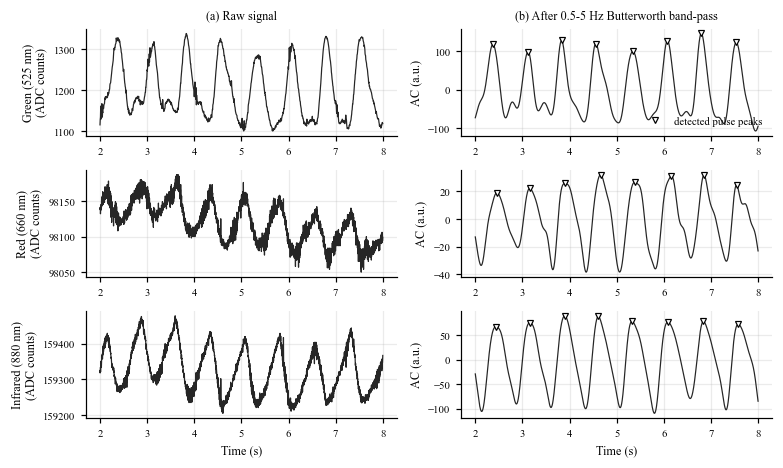

Subjek contoh Fig. 2: S011


In [4]:
# ---------- Fig. 2: mentah vs. terfilter, tiga kanal ----------
best = df.loc[hr[hr.raw_valid].raw_conf.idxmax()]      # rekaman dengan periodisitas terbaik
ir, red, gr = arr(best.infrared_raw), arr(best.red_raw), arr(best.green_raw)
chan = [("Green (525 nm)", gr, FS_GREEN, False),
        ("Red (660 nm)", red, FS_RED, True),
        ("Infrared (880 nm)", ir, FS_IR, True)]

fig, axes = plt.subplots(3, 2, figsize=(PAGE_W, 4.3))
t0, t1 = 2.0, 8.0                                     # jendela 6 s (hindari tepi filter)
for i, (name, x, fs, invert) in enumerate(chan):
    t = np.arange(len(x)) / fs
    m = (t >= t0) & (t <= t1)
    y = ac_signal(x, fs)
    if invert:                                        # kanal reflektif: sistol = cekungan -> dibalik
        y = -y
    axes[i, 0].plot(t[m], x[m], color="0.15", lw=.8)
    axes[i, 1].plot(t[m], y[m], color="0.15", lw=.8)
    pk, _ = find_peaks(y, distance=int(fs * 60 / 180), prominence=0.5 * np.std(y))
    pk = pk[m[pk]]
    axes[i, 1].plot(t[pk], y[pk], "v", ms=3.5, mfc="white", mec="black", mew=.8,
                    label="detected pulse peaks" if i == 0 else None)
    axes[i, 0].set_ylabel(name + "\n(ADC counts)")
    axes[i, 1].set_ylabel("AC (a.u.)")
axes[0, 0].set_title("(a) Raw signal"); axes[0, 1].set_title("(b) After 0.5-5 Hz Butterworth band-pass")
axes[0, 1].legend(loc="lower right", frameon=False)
for a in axes[2]: a.set_xlabel("Time (s)")
fig.tight_layout()
save(fig, "fig2_sinyal_3kanal")
plt.show()
print("Subjek contoh Fig. 2:", best.subject_id)

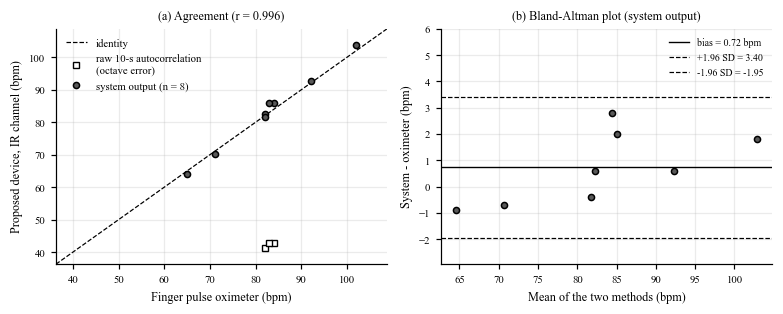

In [5]:
# ---------- Fig. 3: kesesuaian dengan oksimeter jari ----------
S = res["system"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(PAGE_W, 2.9))
allv = pd.concat([hr.oximeter, hr.system_bpm.dropna(), hr.raw_bpm.dropna()])
lo, hi = allv.min() - 5, allv.max() + 5
a1.plot([lo, hi], [lo, hi], "k--", lw=.8, label="identity")
bad = hr[hr.raw_valid & (hr.raw_err.abs() > 20)]
a1.plot(bad.oximeter, bad.raw_bpm, "s", ms=4, mfc="white", mec="black", mew=.9,
        label="raw 10-s autocorrelation\n(octave error)")
a1.plot(vs.oximeter, vs.system_bpm, "o", ms=4, mfc="0.35", mec="black", label="system output (n = %d)" % S["n"])
a1.set_xlim(lo, hi); a1.set_ylim(lo, hi)
a1.set_xlabel("Finger pulse oximeter (bpm)"); a1.set_ylabel("Proposed device, IR channel (bpm)")
a1.set_title(f"(a) Agreement (r = {S['pearson_r']:.3f})"); a1.legend(frameon=False, loc="upper left")

mean_ = (vs.oximeter + vs.system_bpm) / 2
a2.plot(mean_, vs.sys_err, "o", ms=4, mfc="0.35", mec="black")
a2.axhline(S["bias"], color="black", lw=.9, label=f"bias = {S['bias']:.2f} bpm")
a2.axhline(S["loa_high"], color="black", lw=.8, ls="--", label=f"+1.96 SD = {S['loa_high']:.2f}")
a2.axhline(S["loa_low"], color="black", lw=.8, ls="--", label=f"-1.96 SD = {S['loa_low']:.2f}")
a2.set_xlabel("Mean of the two methods (bpm)"); a2.set_ylabel("System - oximeter (bpm)")
a2.set_ylim(S["loa_low"] - 1.0, S["loa_high"] + 2.6)
a2.set_title("(b) Bland-Altman plot (system output)"); a2.legend(frameon=False, loc="upper right", fontsize=6.5)
fig.tight_layout()
save(fig, "fig3_validasi_bpm")
plt.show()